بسم الله

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from tabulate import tabulate

# إعدادات العرض
sns.set(style='whitegrid', palette='muted', color_codes=True)

# النمذجة التنبؤية
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# تثبيت العشوائية
import random
random.seed(42)
np.random.seed(42)

# مكتبة الإحصاء والتحذيرات
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
# محاولة القراءة بترميز مختلف

In [2]:
# Load CSV file
df = pd.read_csv("/kaggle/input/sales-dataset/nigeria_messy_sales_dataset.csv")

# Preview data
print(df.shape)
df.head()

(550, 9)


,Customer Name,State,Product,Units Sold,Unit Price,Total Sale,Sale Date,Sales Channel,Order ID
0,NaN,rivers,KEYBOARD,NaN,NaN,NaN,2025-04-27,Online,NaN
1,Allison Hill,Lagos,Headphones,NaN,267992.94,NaN,2024-03-15,Wholesale,4c636e95-025f-4543-8997-623ae0723d96
2,Noah Rhodes,Anambra,Keyboard,NaN,42364.41,NaN,2024-12-10,NaN,edaf3766-1b78-4ede-9a4f-fc0c9165f2ed
3,Angie Henderson,Delta,Keyboard,NaN,279444.94,NaN,2024-04-05,NaN,74503887-48d9-4846-95c5-51fcfba57cc8
4,Daniel Wagner,Delta,Tablet,NaN,95899.74,NaN,2025-01-12,NaN,8639bd41-8b15-4d94-a42d-0cd7fd359f6a


In [3]:
df.shape


(550, 9)

<Axes: >

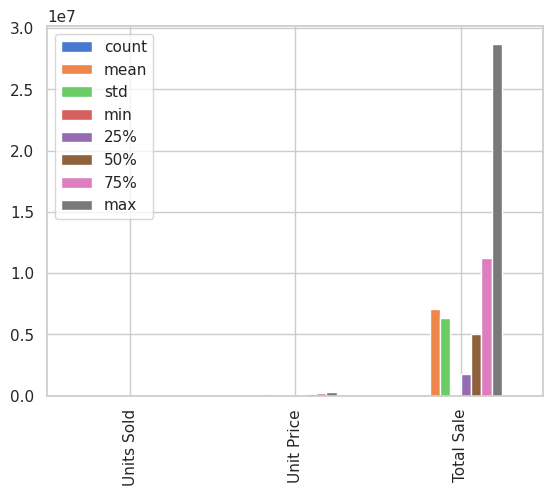

In [4]:
df.describe().T.plot(kind='bar')


In [5]:
# Basic statistics
print('\nStatistical Summary:')
print(df.describe())


Statistical Summary:
       Units Sold     Unit Price    Total Sale
count  155.000000     495.000000  1.370000e+02
mean    46.858065  155703.699212  7.075166e+06
std     26.973156   84443.013217  6.338224e+06
min      1.000000    1403.130000  5.788704e+04
25%     24.500000   84873.975000  1.788402e+06
50%     47.000000  157889.240000  5.049848e+06
75%     67.500000  224577.170000  1.119981e+07
max    100.000000  299437.800000  2.873459e+07


In [6]:
df.isnull().sum()


Customer Name     43
State              0
Product            0
Units Sold       395
Unit Price        55
Total Sale       413
Sale Date          0
Sales Channel    106
Order ID          40
dtype: int64

In [7]:
df.duplicated().sum()


0

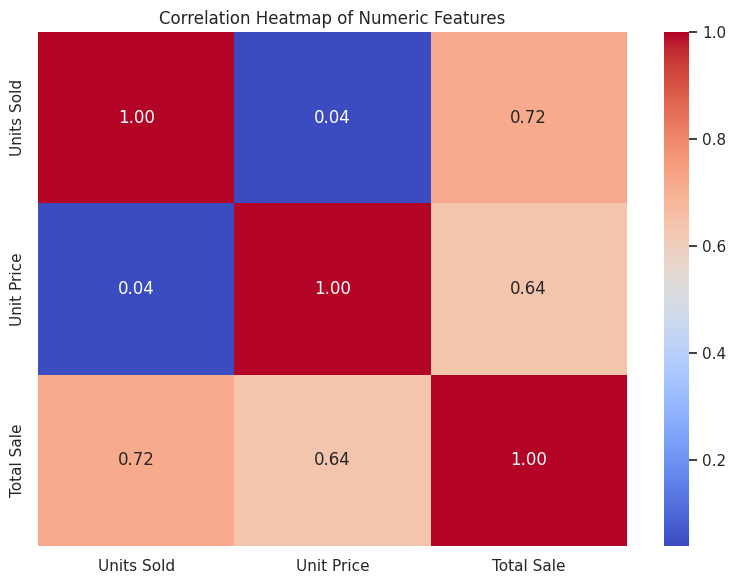

In [8]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation
corr = numeric_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

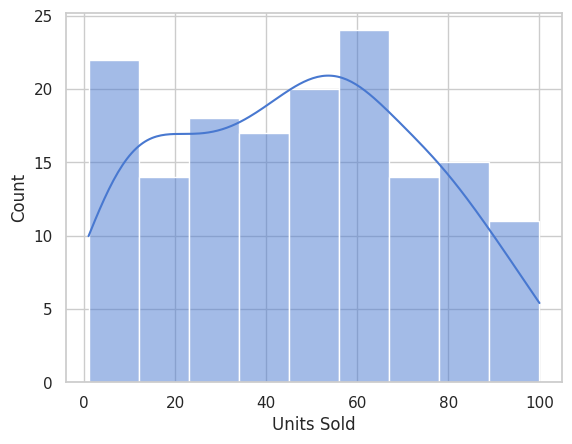

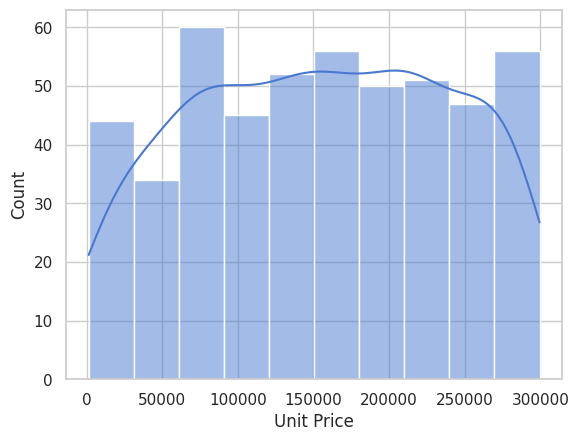

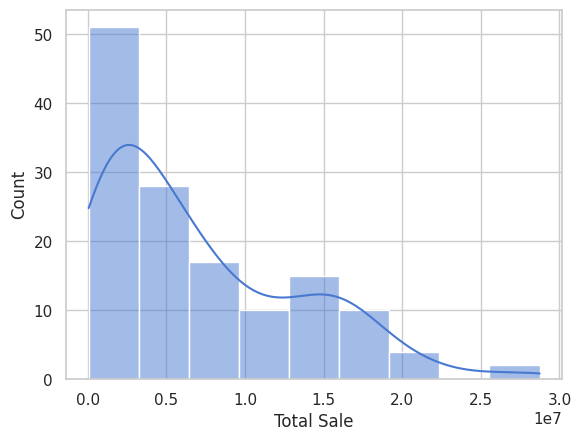

In [9]:
numeric_cols = df.select_dtypes(include=['number']).columns

# رسم التوزيع لكل عمود رقمي
for col in numeric_cols:
    sns.histplot(x=col, data=df, kde=True)
    plt.show()

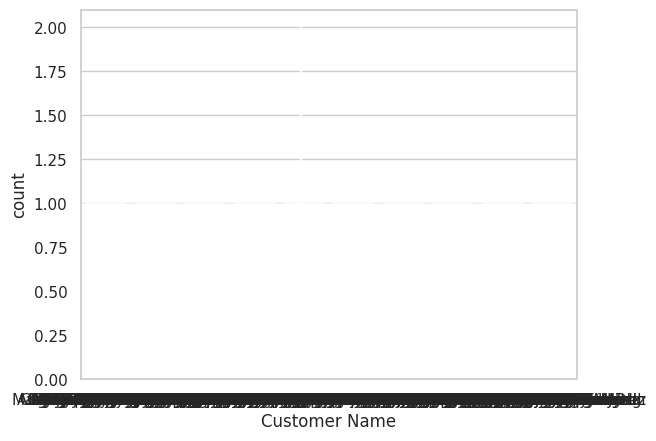

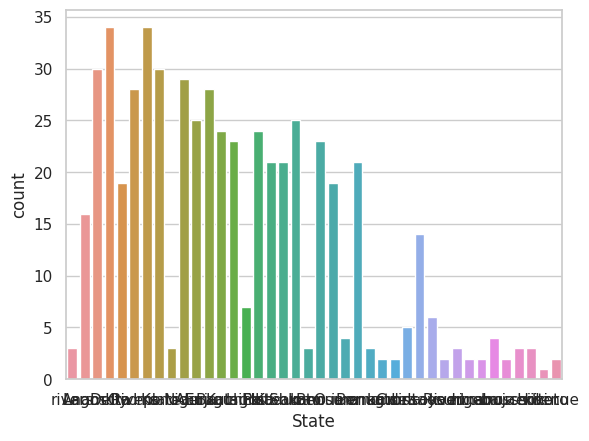

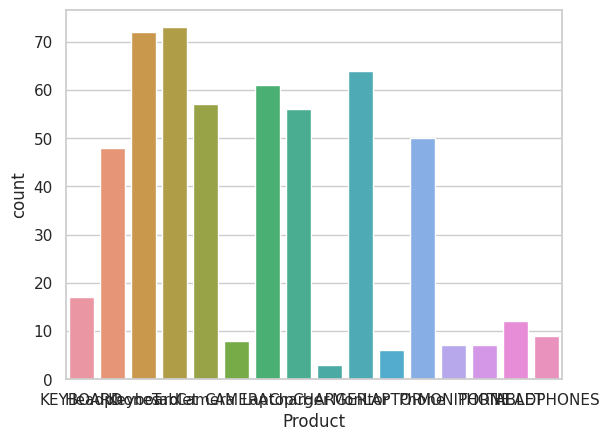

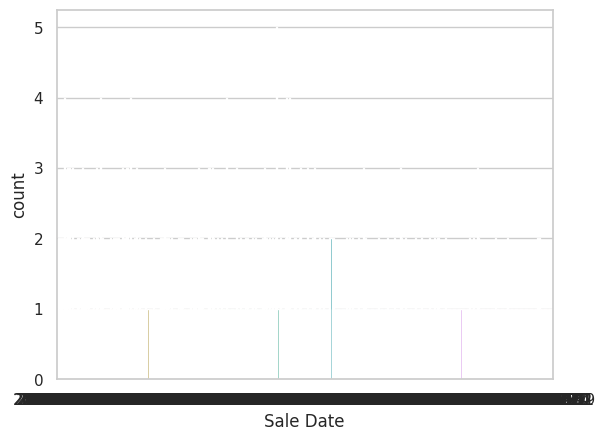

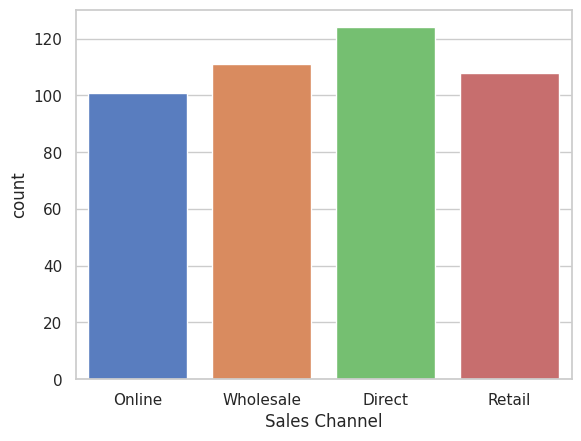

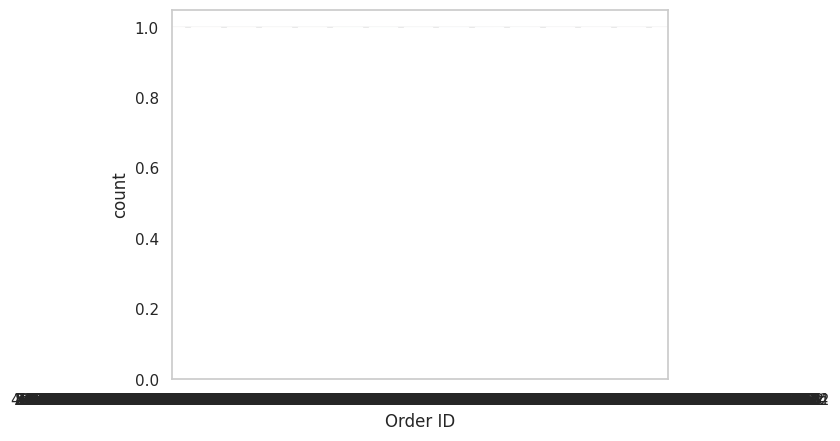

In [10]:
for col in df:
    if df[col].dtype == 'O':
        sns.countplot(x=col,data=df)
        plt.show()